# Chapter 152 — Matrix Representation

> **Prerequisites:** Introduction to Matrices *(ch151)*, vectors *(ch121–124)*  
> **You will learn:**
> - How a linear transformation uniquely determines a matrix (and vice versa)
> - How to read the columns of a matrix as images of basis vectors
> - Row-major vs column-major storage and its performance implications
> - How to extract rows, columns, and submatrices efficiently in NumPy
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

In ch151 we said that every matrix encodes a linear transformation. The inverse is also true: **every linear transformation has exactly one matrix representation** (given a choice of basis).

This bijection — one matrix, one linear map — means that to fully specify a linear transformation on ℝⁿ, you only need to specify where each of the n basis vectors goes. Pack those destinations as columns and you have the matrix.

This chapter makes that correspondence explicit and shows how NumPy's internal storage model affects how you should index and slice matrices in performance-critical code.

**Common misconceptions:**
- *"The matrix is the transformation."* — The matrix is a representation of the transformation in a specific basis. Change the basis, change the matrix, same underlying map.
- *"Row and column indexing are symmetric."* — They are not in memory. NumPy defaults to row-major (C) order; column access is slower than row access.

---

## 2. Intuition & Mental Models

**Geometric:** Think of building a transformation by deciding, one axis at a time, where each coordinate direction should point after the transformation. The matrix is the result of recording all those decisions side by side.

**Computational:** Think of a matrix as a lookup table indexed by output dimension (rows) and input dimension (columns). `A[i, j]` is the contribution of input coordinate j to output coordinate i.

Recall from ch139 (Basis and Dimension) that any vector can be expressed as a linear combination of basis vectors. Once you know where the basis vectors go, linearity forces every other vector's destination. The matrix captures this completely.

---

## 3. Visualization

Matrix A:
[[ 2. -1.]
 [ 1.  2.]]
A[:,0] = [2. 1.]  (image of e1)
A[:,1] = [-1.  2.]  (image of e2)

A @ [3,2] via matmul:      [4. 7.]
3*col1 + 2*col2 via combo: [4. 7.]
Equal: True


C:\Users\user\AppData\Local\Temp\ipykernel_13584\2301070488.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13584\2301070488.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


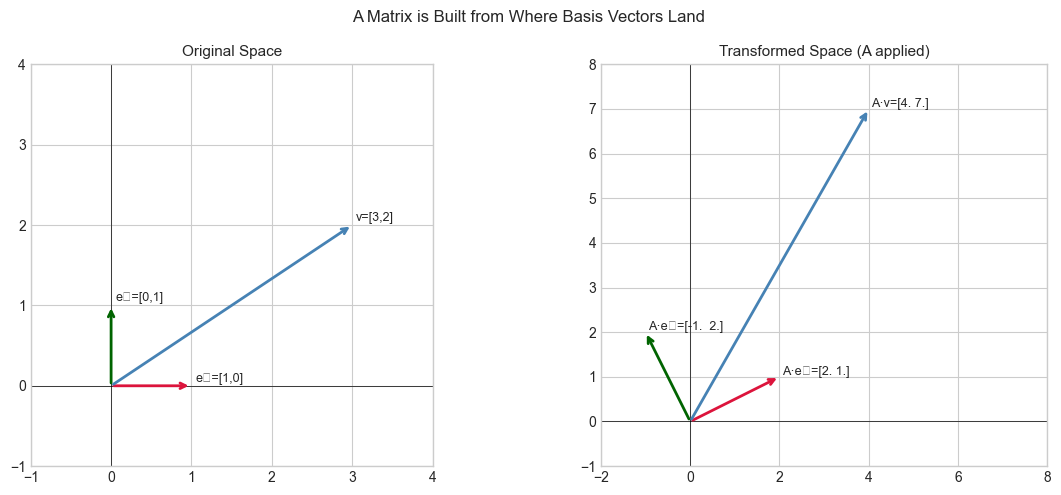

In [1]:
# --- Visualization: Building a matrix column by column ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Define a linear transformation by specifying where basis vectors go
# e1 = [1,0] maps to [2, 1]  (first column)
# e2 = [0,1] maps to [-1, 2] (second column)
col1 = np.array([2.0, 1.0])
col2 = np.array([-1.0, 2.0])
A = np.column_stack([col1, col2])   # pack columns to get matrix

print(f"Matrix A:\n{A}")
print(f"A[:,0] = {A[:,0]}  (image of e1)")
print(f"A[:,1] = {A[:,1]}  (image of e2)")

# Verify: apply A to an arbitrary vector and compare with linear combination
v = np.array([3.0, 2.0])
via_matmul = A @ v
via_combination = v[0] * col1 + v[1] * col2
print(f"\nA @ [3,2] via matmul:      {via_matmul}")
print(f"3*col1 + 2*col2 via combo: {via_combination}")
print(f"Equal: {np.allclose(via_matmul, via_combination)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before transformation
ax = axes[0]
for vec, col, label in [([1,0], 'crimson', 'e₁=[1,0]'), ([0,1], 'darkgreen', 'e₂=[0,1]'), (v, 'steelblue', f'v=[{v[0]:.0f},{v[1]:.0f}]')]:
    vec = np.array(vec)
    ax.annotate('', xy=vec, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(vec[0]+0.05, vec[1]+0.05, label, fontsize=9)
ax.set_xlim(-1, 4); ax.set_ylim(-1, 4); ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Original Space', fontsize=11)

# After transformation
ax = axes[1]
Av = A @ v
for vec, col, label in [(col1, 'crimson', f'A·e₁={col1}'), (col2, 'darkgreen', f'A·e₂={col2}'), (Av, 'steelblue', f'A·v={Av}')]:
    ax.annotate('', xy=vec, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(vec[0]+0.05, vec[1]+0.05, label, fontsize=9)
ax.set_xlim(-2, 8); ax.set_ylim(-1, 8); ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Transformed Space (A applied)', fontsize=11)

plt.suptitle('A Matrix is Built from Where Basis Vectors Land', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Fundamental theorem of matrix representation:**

Given a linear map T: ℝⁿ → ℝᵐ, its matrix [T] is the m×n matrix whose j-th column is T(eⱼ), where eⱼ is the j-th standard basis vector.

```
[T] = [ T(e₁) | T(e₂) | ... | T(eₙ) ]  ← columns are images of basis vectors

# Proof that this works:
# Any v = v₁e₁ + v₂e₂ + ... + vₙeₙ  (decompose in basis)
# T(v) = v₁T(e₁) + ... + vₙT(eₙ)     (linearity of T)
#      = [T] @ v                        (definition of matrix multiplication)
```

**Memory layout (row-major vs column-major):**
```
A = [[1, 2, 3],
     [4, 5, 6]]

C order (row-major, NumPy default):
  memory: [1, 2, 3, 4, 5, 6]  ← rows are contiguous
  fast:   A[i, :]              ← row slice
  slow:   A[:, j]              ← column slice

Fortran order (column-major, used in MATLAB, R, BLAS):
  memory: [1, 4, 2, 5, 3, 6]  ← columns are contiguous
  fast:   A[:, j]              ← column slice
```

In [2]:
# --- Implementation: Indexing, slicing, and memory layout ---
import numpy as np

A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)

# Basic indexing
print("=== Indexing ===")
print(f"A[1, 2] = {A[1, 2]}             # row 1, col 2")
print(f"A[0, :] = {A[0, :]}          # first row")
print(f"A[:, 1] = {A[:, 1]}          # second column")
print(f"A[0:2, 0:2] =\n{A[0:2, 0:2]}  # top-left 2x2 block")
print()

# Memory layout
print("=== Memory Layout ===")
A_C = np.array(A, order='C')   # row-major (default)
A_F = np.array(A, order='F')   # column-major
print(f"C order raw buffer: {A_C.flatten(order='K')}")
print(f"F order raw buffer: {A_F.flatten(order='K')}")
print(f"A_C is C-contiguous: {A_C.flags['C_CONTIGUOUS']}")
print(f"A_F is F-contiguous: {A_F.flags['F_CONTIGUOUS']}")
print()

# Reconstructing a matrix from column vectors
def matrix_from_column_images(images):
    """
    Build a matrix from the list of where basis vectors map.

    Args:
        images: list of 1D arrays, each the image of one basis vector

    Returns:
        2D numpy array, shape (len(images[0]), len(images))
    """
    return np.column_stack(images)

# Define T: e1 -> [1,0,-1], e2 -> [2,1,0], e3 -> [0,3,1]
T_mat = matrix_from_column_images([[1,0,-1], [2,1,0], [0,3,1]])
print(f"Matrix from column images:\n{T_mat}")

=== Indexing ===
A[1, 2] = 6.0             # row 1, col 2
A[0, :] = [1. 2. 3.]          # first row
A[:, 1] = [2. 5. 8.]          # second column
A[0:2, 0:2] =
[[1. 2.]
 [4. 5.]]  # top-left 2x2 block

=== Memory Layout ===
C order raw buffer: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
F order raw buffer: [1. 4. 7. 2. 5. 8. 3. 6. 9.]
A_C is C-contiguous: True
A_F is F-contiguous: True

Matrix from column images:
[[ 1  2  0]
 [ 0  1  3]
 [-1  0  1]]


---

## 5. Python Implementation

In [3]:
# --- Implementation: Recover a transformation matrix from function evaluation ---
import numpy as np

def linear_map_to_matrix(T_func, input_dim, output_dim=None):
    """
    Given a linear function T: R^n -> R^m, compute its matrix.
    Uses the fundamental theorem: column j = T(e_j).

    Args:
        T_func: callable, accepts 1D array of length input_dim
        input_dim: n, dimension of input space
        output_dim: m (inferred if None)

    Returns:
        2D numpy array of shape (output_dim, input_dim)
    """
    columns = []
    for j in range(input_dim):
        e_j = np.zeros(input_dim)
        e_j[j] = 1.0                 # j-th standard basis vector
        columns.append(T_func(e_j))  # T(e_j) is the j-th column
    return np.column_stack(columns)

# Test: define a transformation as a Python function
def my_transform(v):
    """Rotate and scale: x' = 2x - y, y' = x + y, z' = 3z"""
    return np.array([
        2*v[0] - v[1],
        v[0] + v[1],
        3*v[2]
    ])

M = linear_map_to_matrix(my_transform, input_dim=3)
print(f"Recovered matrix:\n{M}")

# Verify on a test vector
test_v = np.array([1.0, 2.0, 3.0])
print(f"\nDirect function:  {my_transform(test_v)}")
print(f"Via matrix:       {M @ test_v}")
print(f"Match: {np.allclose(my_transform(test_v), M @ test_v)}")

Recovered matrix:
[[ 2. -1.  0.]
 [ 1.  1.  0.]
 [ 0.  0.  3.]]

Direct function:  [0. 3. 9.]
Via matrix:       [0. 3. 9.]
Match: True


---

## 6. Experiments

In [4]:
# --- Experiment: Row access vs column access speed ---
# Hypothesis: In row-major storage, row access is faster than column access.
# Try changing: N to see how the gap scales.
import numpy as np
import time

N = 2000   # <-- try 500, 2000, 5000
A = np.random.randn(N, N)
A_F = np.asfortranarray(A)

REPS = 200

# Row access on C-order
t0 = time.perf_counter()
for _ in range(REPS):
    for i in range(0, N, N//10):
        _ = A[i, :].sum()
t_row_C = (time.perf_counter() - t0) / REPS

# Column access on C-order
t0 = time.perf_counter()
for _ in range(REPS):
    for j in range(0, N, N//10):
        _ = A[:, j].sum()
t_col_C = (time.perf_counter() - t0) / REPS

print(f"N = {N}")
print(f"Row access (C-order):    {t_row_C*1000:.3f} ms")
print(f"Column access (C-order): {t_col_C*1000:.3f} ms")
print(f"Column/Row ratio: {t_col_C/t_row_C:.2f}x")
print("\nFor small N the gap is negligible; for large N, memory layout matters.")

N = 2000
Row access (C-order):    0.038 ms
Column access (C-order): 0.286 ms
Column/Row ratio: 7.44x

For small N the gap is negligible; for large N, memory layout matters.


---

## 7. Exercises

**Easy 1.** Given the transformation T(x, y) = (3x + y, x - 2y), write down its 2×2 matrix by hand. Verify by computing T([1,0]) and T([0,1]).

**Easy 2.** For a 4×6 matrix A, what is the shape of A[1:3, 2:5]? What is the shape of A[:, ::2]?

**Medium 1.** Use `linear_map_to_matrix` to recover the matrix of the transformation T(x,y,z) = (x+y, y+z, x+z). Verify it against the manually constructed matrix.

**Medium 2.** Write a function `column_view(A)` that returns a Fortran-order copy of A, then benchmark column access on both C-order and F-order for a 1000×1000 matrix.

**Hard.** Prove computationally that any function satisfying T(au + bv) = aT(u) + bT(v) (linearity) is completely determined by its values on the standard basis. Generate 5 random linear functions (as random matrices), compute their values on 100 random vectors, and verify that the matrix recovered by `linear_map_to_matrix` exactly matches `A @ v` for all test vectors.

---

## 8. Mini Project

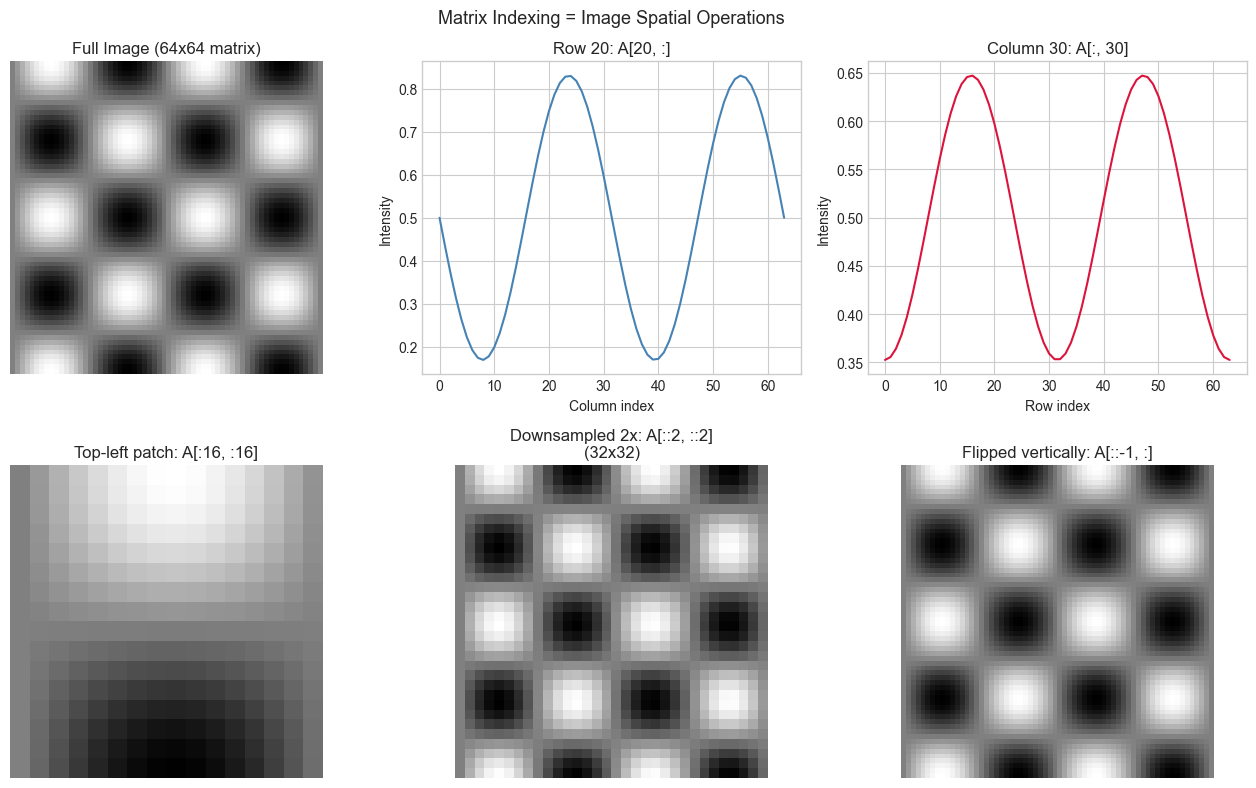

In [5]:
# --- Mini Project: Image as a Matrix ---
# Problem: A grayscale image is literally a 2D matrix of pixel intensities.
# Task: Generate a synthetic image, then access specific rows/columns/patches
# and show how matrix indexing maps to spatial image operations.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Generate a synthetic 64x64 'image' with structure
SIZE = 64
x = np.linspace(0, 4*np.pi, SIZE)
y = np.linspace(0, 4*np.pi, SIZE)
X, Y = np.meshgrid(x, y)
image = (np.sin(X) * np.cos(Y) + 1) / 2   # range [0, 1]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

axes[0,0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0,0].set_title('Full Image (64x64 matrix)')

# Row 20: a horizontal slice of the image
axes[0,1].plot(image[20, :], color='steelblue')
axes[0,1].set_title('Row 20: A[20, :]')
axes[0,1].set_xlabel('Column index'); axes[0,1].set_ylabel('Intensity')

# Column 30: a vertical slice
axes[0,2].plot(image[:, 30], color='crimson')
axes[0,2].set_title('Column 30: A[:, 30]')
axes[0,2].set_xlabel('Row index'); axes[0,2].set_ylabel('Intensity')

# Top-left 16x16 patch
patch = image[:16, :16]
axes[1,0].imshow(patch, cmap='gray', vmin=0, vmax=1)
axes[1,0].set_title('Top-left patch: A[:16, :16]')

# Every other row and column (downsampling)
downsampled = image[::2, ::2]
axes[1,1].imshow(downsampled, cmap='gray', vmin=0, vmax=1)
axes[1,1].set_title(f'Downsampled 2x: A[::2, ::2]\n({downsampled.shape[0]}x{downsampled.shape[1]})')

# Flipped image (reverse rows)
flipped = image[::-1, :]
axes[1,2].imshow(flipped, cmap='gray', vmin=0, vmax=1)
axes[1,2].set_title('Flipped vertically: A[::-1, :]')

for ax in axes.flat: ax.axis('off') if ax.get_images() else None
plt.suptitle('Matrix Indexing = Image Spatial Operations', fontsize=13)
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

- Every linear transformation T: ℝⁿ → ℝᵐ has exactly one m×n matrix, with j-th column = T(eⱼ).
- The matrix is the representation of the transformation in the standard basis — changing basis changes the matrix but not the map.
- NumPy uses C (row-major) order by default; column access is non-contiguous and slower for large matrices.
- `linear_map_to_matrix` — probing a black-box linear function with basis vectors — is the foundation of how automatic differentiation works *(reappears in ch208 — Automatic Differentiation)*.

**Backward connection:** The basis decomposition argument here is a direct application of ch139 (Basis and Dimension) — vectors as linear combinations of basis vectors.

**Forward connections:**
- In ch165 (Matrix Transformations Visualization), we will use this column-image view to visualize *every* transformation in Part VI.
- In ch176 (Matrix Calculus Introduction), the Jacobian matrix is constructed exactly this way: its columns are partial derivatives with respect to each input — the linear approximation to a nonlinear function at a point.